In [2]:
# EXPERIMENT 8 - AIML LAB
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# READ DATASET (local file)
df = pd.read_csv("titanic.csv")
print("\nOriginal Dataset Shape:", df.shape)


Original Dataset Shape: (891, 15)


In [3]:
# SELECT ONLY NUMERICAL COLUMNS
X = df.select_dtypes(include=['number'])

# Fill missing values to avoid PCA errors
X = X.fillna(X.mean())

# FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# APPLY PCA
pca = PCA(n_components=2)   # reduce to 2 dimensions
X_pca = pca.fit_transform(X_scaled)

# CREATE NEW DATAFRAME
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])


===== PCA RESULT (First 5 Rows) =====
        PC1       PC2
0  1.335989  0.302728
1 -2.074980 -0.425153
2  0.435339 -0.285895
3 -1.804092 -0.370184
4  1.137755 -0.718825

Explained Variance Ratio:
[0.30992303 0.27319996]


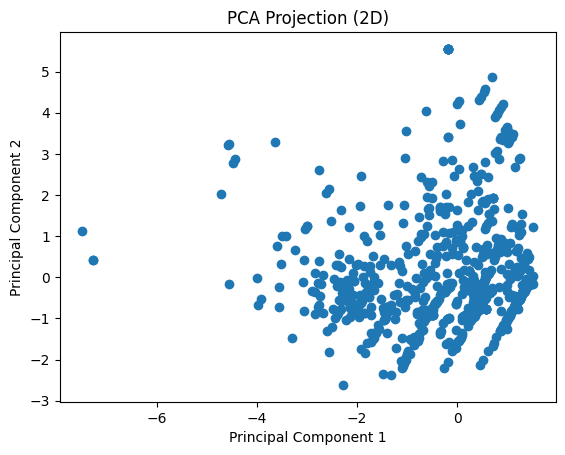


PCA output saved as: pca_output.csv


In [4]:
print("\n===== PCA RESULT (First 5 Rows) =====")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# GRAPH (IMPORTANT)
plt.figure()
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.title("PCA Projection (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


# EXPORT RESULT
output_file = "pca_output.csv"
pca_df.to_csv(output_file, index=False)

print("\nPCA output saved as:", output_file)